In [1]:
# train_classification_models.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import plot_tree
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
INPUT_FILE = "input_data.csv"
PROCESSED_FILE = "processed_traffic_data.csv"

In [3]:
def preprocess_traffic_data(input_filename=INPUT_FILE, output_filename= PROCESSED_FILE ):
    # Load the data
    print("Loading data...")
    df = pd.read_csv(input_filename)  # Avoid mixed type warning
    print(f"Processing {len(df)} rows...")

    # Handle missing values in numerical columns
    imputer = SimpleImputer(strategy='mean')
    df['Vehicle_Count'] = imputer.fit_transform(df[['Vehicle_Count']])
    df['Average_Speed'] = imputer.fit_transform(df[['Average_Speed']])

    # Impute missing categorical values with mode
    categorical_cols = ['Weather_Condition', 'Road_Type', 'Location', 'Vehicle_Type', 'Road_Condition']
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Step 2: Normalize numerical features
    scaler = StandardScaler()
    df[['Vehicle_Count', 'Average_Speed']] = scaler.fit_transform(df[['Vehicle_Count', 'Average_Speed']])

    joblib.dump(scaler, 'numerical_scaler.pkl')

    # Step 3: Encode categorical features
    label_encoder = LabelEncoder()
    for col in categorical_cols:
        df[col] = label_encoder.fit_transform(df[col])

    # Step 4: Save the processed dataset
    df.to_csv(output_filename, index=False)
    print(f"Processed data saved to {output_filename}")
    return df

df = preprocess_traffic_data()

Loading data...
Processing 8800000 rows...
Processed data saved to processed_traffic_data.csv


Starting model training...
Loading and sampling data...
Processing 7040000 rows...
Training set size: 5632000, Test set size: 1408000
Training SVM model...
SVM model trained.
Training Decision Tree model...
Decision Tree model trained.
Training Random Forest model...
Random Forest model trained.

Generating Visualizations and Reports...


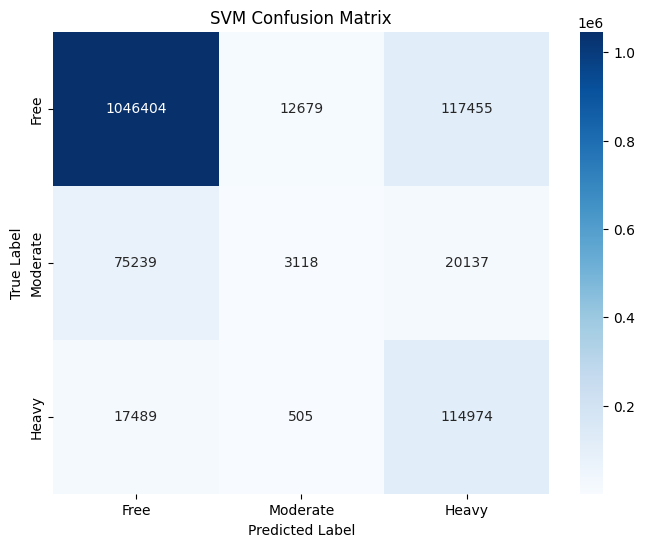

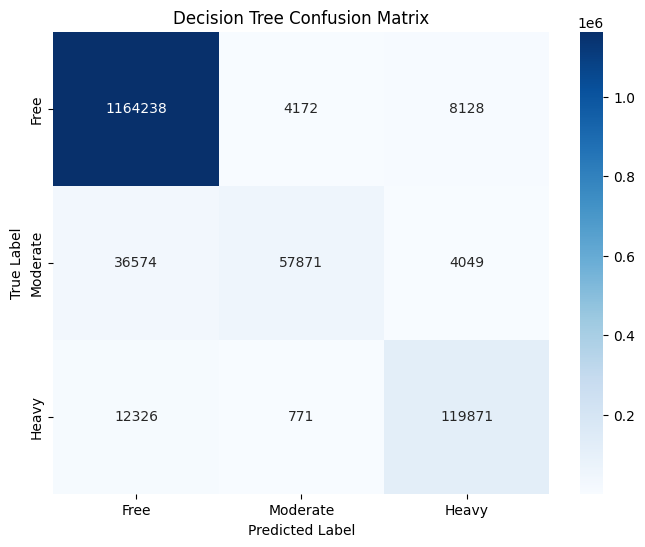

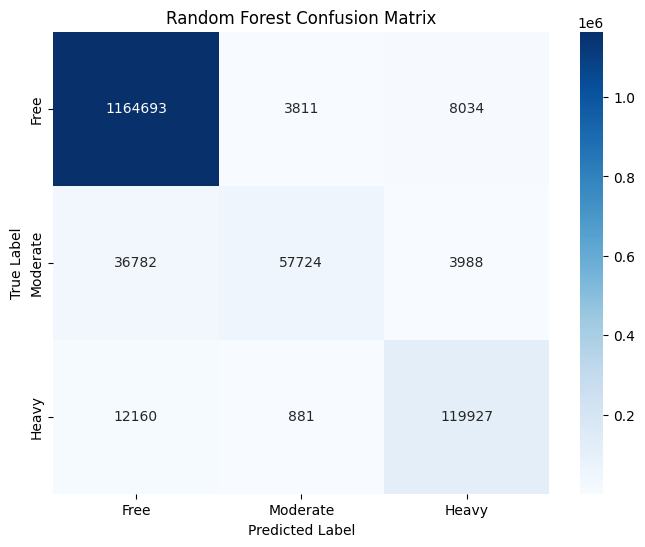

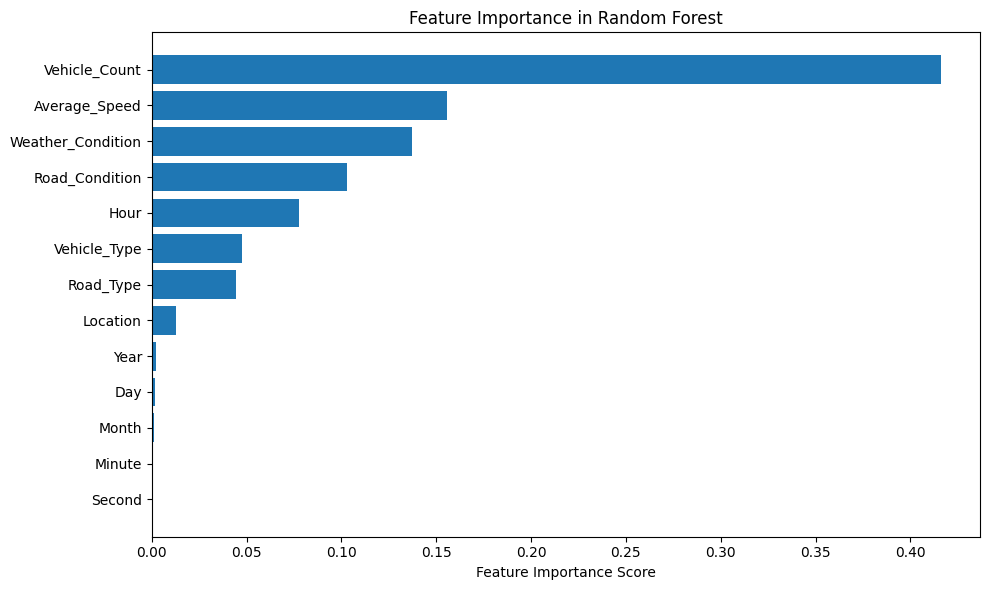

SVM Classification Report:
               precision    recall  f1-score   support

        Free       0.92      0.89      0.90   1176538
    Moderate       0.19      0.03      0.05     98494
       Heavy       0.46      0.86      0.60    132968

    accuracy                           0.83   1408000
   macro avg       0.52      0.60      0.52   1408000
weighted avg       0.82      0.83      0.82   1408000

Decision Tree Classification Report:
               precision    recall  f1-score   support

        Free       0.96      0.99      0.97   1176538
    Moderate       0.92      0.59      0.72     98494
       Heavy       0.91      0.90      0.90    132968

    accuracy                           0.95   1408000
   macro avg       0.93      0.83      0.87   1408000
weighted avg       0.95      0.95      0.95   1408000

Random Forest Classification Report:
               precision    recall  f1-score   support

        Free       0.96      0.99      0.97   1176538
    Moderate       0.92  

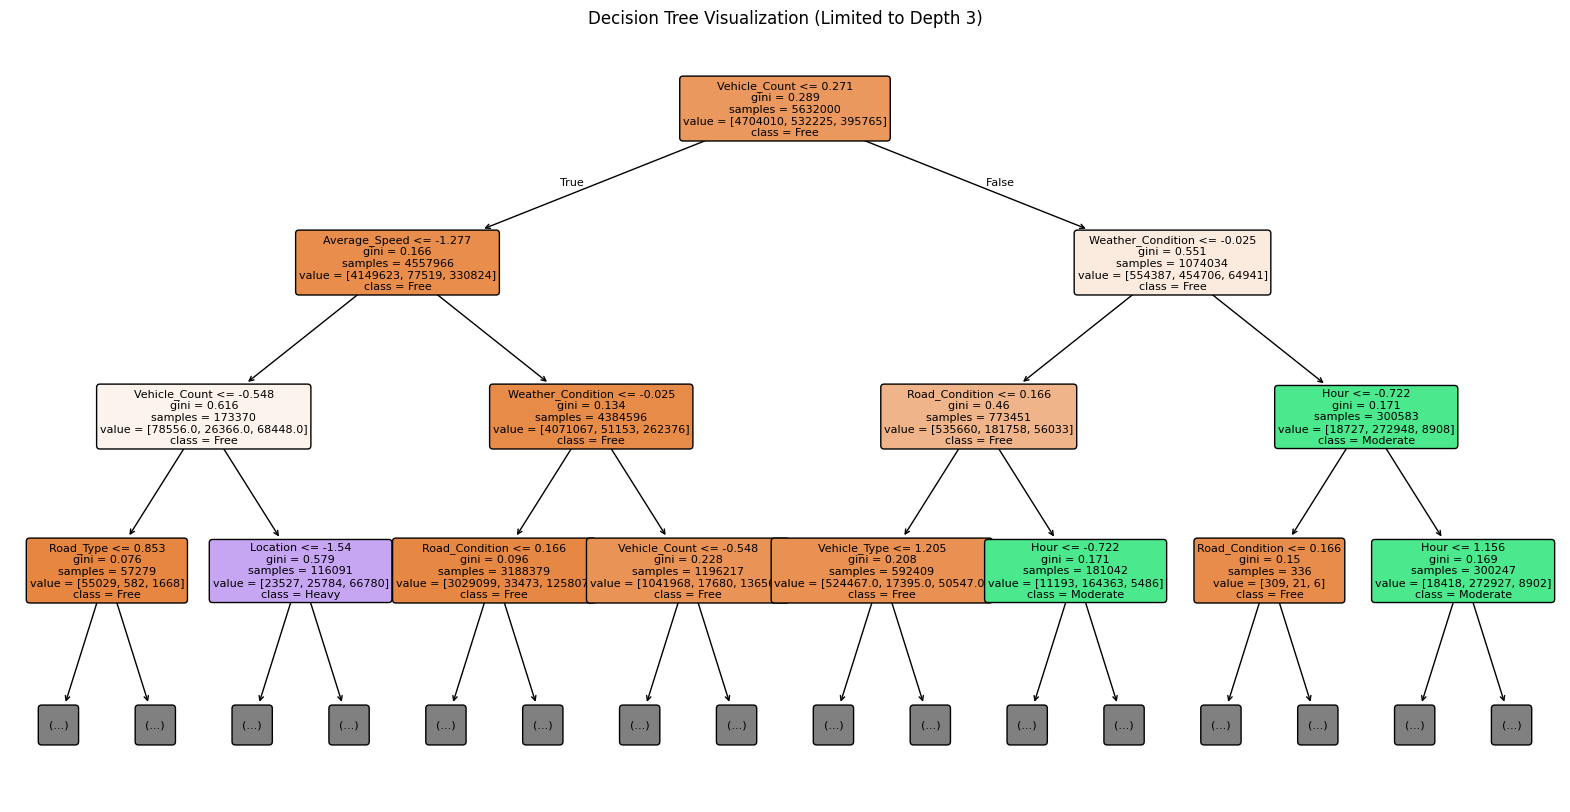

Training complete!


In [4]:
# Constants
INPUT_FILE = "processed_traffic_data.csv"
SAMPLE_FRAC = 0.8  # Consistent with other scripts

def plot_confusion_matrices(y_test, svm_preds, dt_preds, rf_preds):
    """
    Plot confusion matrices for SVM, Decision Tree, and Random Forest models.
    """
    class_labels = ['Free', 'Moderate', 'Heavy']

    # SVM Confusion Matrix
    cm_svm = confusion_matrix(y_test, svm_preds, labels=class_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('SVM Confusion Matrix')
    plt.show()

    # Decision Tree Confusion Matrix
    cm_dt = confusion_matrix(y_test, dt_preds, labels=class_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Decision Tree Confusion Matrix')
    plt.show()

    # Random Forest Confusion Matrix
    cm_rf = confusion_matrix(y_test, rf_preds, labels=class_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Random Forest Confusion Matrix')
    plt.show()

def plot_feature_importances(rf_model, X_train):
    """
    Plot feature importances from the Random Forest model.
    """
    feature_importances = rf_model.feature_importances_
    feature_names = X_train.columns
    indices = np.argsort(feature_importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(feature_importances)), feature_importances[indices], align="center")
    plt.yticks(range(len(feature_importances)), [feature_names[i] for i in indices])
    plt.xlabel("Feature Importance Score")
    plt.title("Feature Importance in Random Forest")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def print_classification_reports(y_test, svm_preds, dt_preds, rf_preds):
    """
    Print classification reports for all models.
    """
    class_labels = ['Free', 'Moderate', 'Heavy']
    print("SVM Classification Report:\n", 
          classification_report(y_test, svm_preds, labels=class_labels, zero_division=0))
    print("Decision Tree Classification Report:\n", 
          classification_report(y_test, dt_preds, labels=class_labels, zero_division=0))
    print("Random Forest Classification Report:\n", 
          classification_report(y_test, rf_preds, labels=class_labels, zero_division=0))

def plot_decision_tree(dt_model, X_train):
    """
    Visualize the Decision Tree structure.
    """
    feature_names = X_train.columns.tolist()
    class_names = ['Free', 'Moderate', 'Heavy']

    plt.figure(figsize=(20, 10))
    plot_tree(dt_model, feature_names=feature_names, class_names=class_names, 
              filled=True, rounded=True, fontsize=8, max_depth=3)
    plt.title("Decision Tree Visualization (Limited to Depth 3)")
    plt.show()

def train_classification_models(input_filename=INPUT_FILE, sample_frac=SAMPLE_FRAC):
    print("Loading and sampling data...")
    try:
        df = pd.read_csv(input_filename, low_memory=False).sample(frac=sample_frac, random_state=42)
    except FileNotFoundError:
        print(f"File {input_filename} not found.")
        return
    except pd.errors.EmptyDataError:
        print(f"File {input_filename} is empty.")
        return
    print(f"Processing {len(df)} rows...")

    # Feature engineering
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df['Year'] = df['Date'].dt.year.fillna(0)
        df['Month'] = df['Date'].dt.month.fillna(0)
        df['Day'] = df['Date'].dt.day.fillna(0)
        df = df.drop(columns=['Date'])

    if 'Time' in df.columns:
        df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')
        df['Hour'] = df['Time'].dt.hour.fillna(0)
        df['Minute'] = df['Time'].dt.minute.fillna(0)
        df['Second'] = df['Time'].dt.second.fillna(0)
        df = df.drop(columns=['Time'])

    # Split features and target
    if 'Traffic_Flow' not in df.columns:
        print("Column 'Traffic_Flow' not found in the dataframe.")
        return
    X = df.drop(columns=['Traffic_Flow'])
    y = df['Traffic_Flow']

    # Ensure numeric and scale all features
    X = X.apply(pd.to_numeric, errors='coerce')
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X = X.fillna(0)

    # Ensure numeric and scale all features
    X = X.apply(pd.to_numeric, errors='coerce')
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X = X.fillna(0)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")

    # Define models
    svm_model = LinearSVC(max_iter=5000, random_state=42, class_weight='balanced')
    dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

    # Train models
    print("Training SVM model...")
    svm_model.fit(X_train, y_train)
    print("SVM model trained.")

    print("Training Decision Tree model...")
    dt_model.fit(X_train, y_train)
    print("Decision Tree model trained.")

    print("Training Random Forest model...")
    rf_model.fit(X_train, y_train)
    print("Random Forest model trained.")

    # Predictions
    svm_preds = svm_model.predict(X_test)
    dt_preds = dt_model.predict(X_test)
    rf_preds = rf_model.predict(X_test)

    # Visualizations and Reports
    print("\nGenerating Visualizations and Reports...")
    plot_confusion_matrices(y_test, svm_preds, dt_preds, rf_preds)
    plot_feature_importances(rf_model, X_train)
    print_classification_reports(y_test, svm_preds, dt_preds, rf_preds)
    plot_decision_tree(dt_model, X_train)

    return X_train, X_test, y_train, y_test, svm_preds, dt_preds, rf_preds, svm_model, dt_model, rf_model

# Execute
if __name__ == "__main__":
    print("Starting model training...")
    result = train_classification_models()
    if result:
        X_train, X_test, y_train, y_test, svm_preds, dt_preds, rf_preds, svm_model, dt_model, rf_model = result
        print("Training complete!")

Loading data for anomaly detection...
Processing 88000 rows...


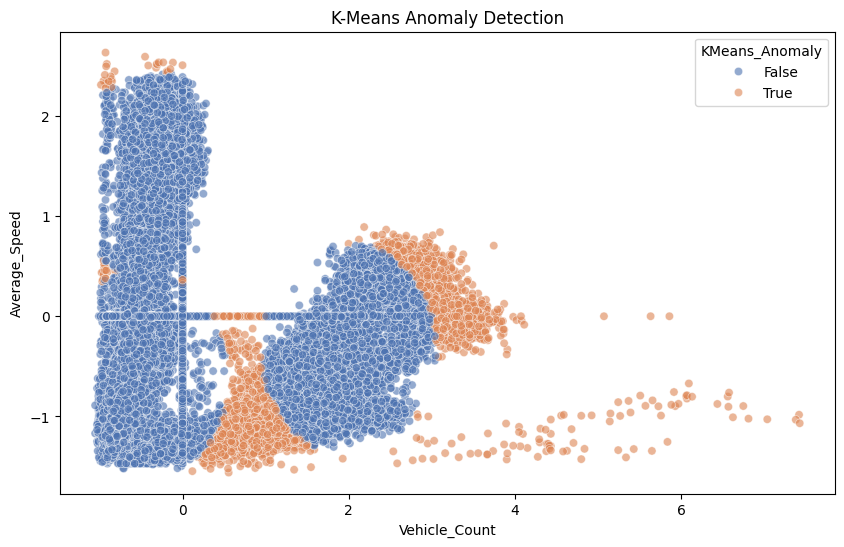

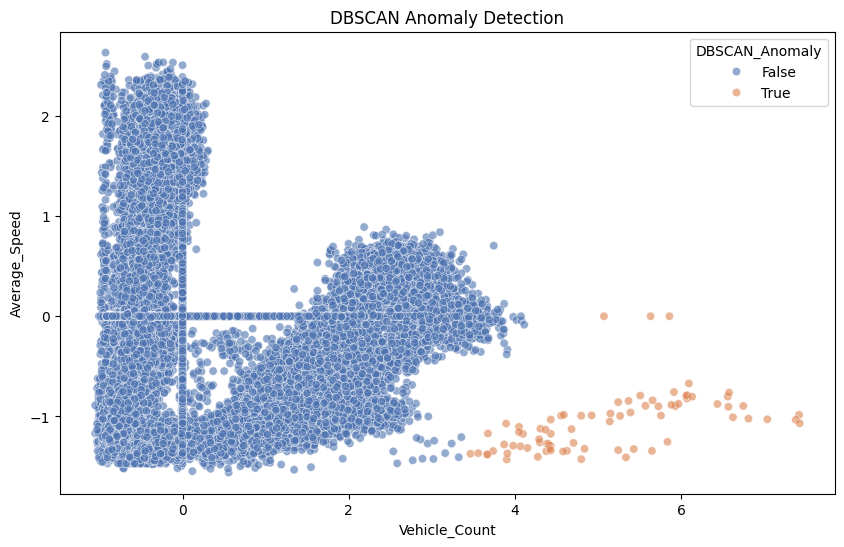

Anomaly results saved to 'anomaly_results.csv'


In [ ]:
# anomaly_detection.py
INPUT_FILE = "processed_traffic_data.csv"
SAMPLE_FRAC = 0.1

def detect_anomalies(input_filename=INPUT_FILE, sample_frac=SAMPLE_FRAC):
    """
    Detect anomalies in traffic data using K-Means and DBSCAN.
    """
    print("Loading data for anomaly detection...")
    df = pd.read_csv(input_filename, low_memory=False).sample(frac=sample_frac, random_state=42)
    print(f"Processing {len(df)} rows...")

    # Feature engineering (to match generate_insights.py)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df['Year'] = df['Date'].dt.year.fillna(0)
        df['Month'] = df['Date'].dt.month.fillna(0)
        df['Day'] = df['Date'].dt.day.fillna(0)
        df = df.drop(columns=['Date'])

    if 'Time' in df.columns:
        df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')
        df['Hour'] = df['Time'].dt.hour.fillna(0)
        df['Minute'] = df['Time'].dt.minute.fillna(0)
        df['Second'] = df['Time'].dt.second.fillna(0)
        df = df.drop(columns=['Time'])

    # Select key features
    X = df[['Vehicle_Count', 'Average_Speed']].apply(pd.to_numeric, errors='coerce').fillna(0)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    joblib.dump(scaler, 'scaler.pkl')

    # K-Means Clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
    distances = kmeans.transform(X_scaled).min(axis=1)
    df['KMeans_Anomaly'] = distances > np.percentile(distances, 95)  # Top 5% farthest points

    # DBSCAN Clustering
    dbscan = DBSCAN(eps=0.5, min_samples=50)
    df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
    df['DBSCAN_Anomaly'] = df['DBSCAN_Cluster'] == -1  # Noise points as anomalies

    # Visualizations
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Vehicle_Count', y='Average_Speed', hue='KMeans_Anomaly', palette='deep', alpha=0.6)
    plt.title('K-Means Anomaly Detection')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Vehicle_Count', y='Average_Speed', hue='DBSCAN_Anomaly', palette='deep', alpha=0.6)
    plt.title('DBSCAN Anomaly Detection')
    plt.show()

    # Save results
    df.to_csv('anomaly_results.csv', index=False)
    print("Anomaly results saved to 'anomaly_results.csv'")
    return df

# Execute
if __name__ == "__main__":
    detect_anomalies()

Loading data for regression...
Processing 2640000 rows...
Training set size: 2112000, Test set size: 528000
Training Linear Regression...
Training Random Forest Regression...
Random Forest Regressor model saved to 'rf_regression_model.pkl'
Linear Regression RMSE: 0.9455
Random Forest Regression RMSE: 0.3138


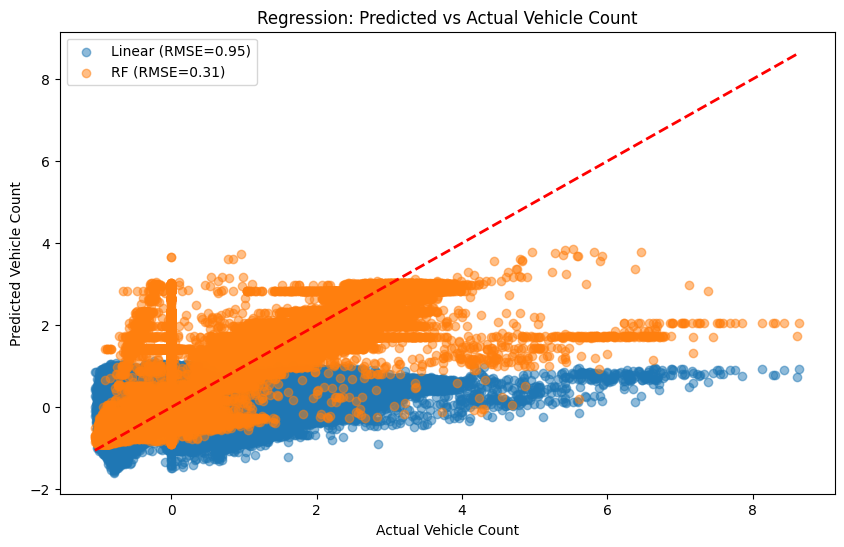

In [9]:
# regression_analysis.py
INPUT_FILE = "processed_traffic_data.csv"
SAMPLE_FRAC = 0.3  # Already 0.01

def regression_analysis(input_filename=INPUT_FILE, sample_frac=SAMPLE_FRAC):
    """
    Perform regression to predict Vehicle_Count trends.
    """
    print("Loading data for regression...")
    df = pd.read_csv(input_filename, low_memory=False).sample(frac=sample_frac, random_state=42)
    print(f"Processing {len(df)} rows...")

    # Feature engineering (same as classification)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df['Year'] = df['Date'].dt.year.fillna(0)
        df['Month'] = df['Date'].dt.month.fillna(0)
        df['Day'] = df['Date'].dt.day.fillna(0)
        df = df.drop(columns=['Date'])

    if 'Time' in df.columns:
        df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')
        df['Hour'] = df['Time'].dt.hour.fillna(0)
        df['Minute'] = df['Time'].dt.minute.fillna(0)
        df['Second'] = df['Time'].dt.second.fillna(0)
        df = df.drop(columns=['Time'])

    # Features and target
    X = df.drop(columns=['Vehicle_Count', 'Traffic_Flow'])  # Exclude target and classification label
    y = df['Vehicle_Count'].apply(pd.to_numeric, errors='coerce').fillna(df['Vehicle_Count'].mean())  # Ensure y is numeric, fill NaNs with mean

    # Clean X
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")

    # Models
    lr_model = LinearRegression()
    rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

    # Train
    print("Training Linear Regression...")
    lr_model.fit(X_train, y_train)
    print("Training Random Forest Regression...")
    rf_model.fit(X_train, y_train)

    # Save the Random Forest Regressor
    joblib.dump(rf_model, 'rf_regression_model.pkl')
    print("Random Forest Regressor model saved to 'rf_regression_model.pkl'")

    # Predict
    lr_preds = lr_model.predict(X_test)
    rf_preds = rf_model.predict(X_test)

    # Evaluate
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
    print(f"Linear Regression RMSE: {lr_rmse:.4f}")
    print(f"Random Forest Regression RMSE: {rf_rmse:.4f}")

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, lr_preds, alpha=0.5, label=f'Linear (RMSE={lr_rmse:.2f})')
    plt.scatter(y_test, rf_preds, alpha=0.5, label=f'RF (RMSE={rf_rmse:.2f})')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Vehicle Count')
    plt.ylabel('Predicted Vehicle Count')
    plt.title('Regression: Predicted vs Actual Vehicle Count')
    plt.legend()
    plt.show()

    return lr_model, rf_model, lr_rmse, rf_rmse

# Execute
if __name__ == "__main__":
    regression_analysis()

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Constants
PROCESSED_FILE = "processed_traffic_data.csv"
ANOMALY_FILE = "anomaly_results.csv"
SAMPLE_FRAC = 0.1  # Consistent with other scripts

def generate_insights(processed_file=PROCESSED_FILE, anomaly_file=ANOMALY_FILE, sample_frac=SAMPLE_FRAC):
    """
    Generate actionable insights from classification, anomaly detection, and regression results.
    """
    # Load data
    print("Loading processed data for insights...")
    try:
        df_processed = pd.read_csv(processed_file, low_memory=False, dtype={'Date': str, 'Time': str})
        # Stratified sampling to ensure representation of all hours
        df_processed = df_processed.groupby('Hour', group_keys=False).apply(lambda x: x.sample(frac=sample_frac, random_state=42))
    except FileNotFoundError:
        print(f"Error: {processed_file} not found. Ensure you've run the preprocessing and add_traffic_flow steps.")
        return

    print("Loading anomaly results...")
    try:
        df_anomaly = pd.read_csv(anomaly_file, low_memory=False)
    except FileNotFoundError:
        print(f"Error: {anomaly_file} not found. Ensure you've run the anomaly detection step.")
        return

    # Extract Year, Month, Day from Date and Minute, Second from Time
    df_processed['Date'] = pd.to_datetime(df_processed['Date'], format='%m/%d/%y', errors='coerce')
    df_processed['Year'] = df_processed['Date'].dt.year
    df_processed['Month'] = df_processed['Date'].dt.month
    df_processed['Day'] = df_processed['Date'].dt.day

    df_processed['Time'] = pd.to_datetime(df_processed['Time'], format='%H:%M:%S', errors='coerce')
    df_processed['Minute'] = df_processed['Time'].dt.minute
    df_processed['Second'] = df_processed['Time'].dt.second

    # Fill any missing values after extraction
    df_processed[['Year', 'Month', 'Day', 'Minute', 'Second']] = df_processed[['Year', 'Month', 'Day', 'Minute', 'Second']].fillna(0).astype(int)

    # Decode categorical columns back to their original values for readability
    weather_conditions = {0: 'Clear', 1: 'Rainy', 2: 'Foggy', 3: 'Snowy'}
    road_types = {0: 'Highway', 1: 'Urban', 2: 'Residential'}
    locations = {0: 'Highway A', 1: 'Downtown', 2: 'Main Road', 3: 'City Center'}
    vehicle_types = {0: 'Car', 1: 'Truck', 2: 'Motorbike', 3: 'Bus'}
    road_conditions = {0: 'Good', 1: 'Under Construction', 2: 'Potholes'}

    for col, mapping in [('Weather_Condition', weather_conditions),
                         ('Road_Type', road_types),
                         ('Location', locations),
                         ('Vehicle_Type', vehicle_types),
                         ('Road_Condition', road_conditions)]:
        if df_processed[col].dtype in [int, float]:
            df_processed[col] = df_processed[col].map(mapping).fillna(df_processed[col])

    # Merge df_processed and df_anomaly on index
    df_combined = df_processed.join(df_anomaly[['KMeans_Anomaly', 'DBSCAN_Anomaly', 'KMeans_Cluster', 'DBSCAN_Cluster']], how='left')
    df_combined[['KMeans_Anomaly', 'DBSCAN_Anomaly']] = df_combined[['KMeans_Anomaly', 'DBSCAN_Anomaly']].fillna(False)

    # Load the Random Forest Classifier model
    print("Loading Random Forest Classifier model...")
    try:
        rf_clf_model = joblib.load('rf_classification_model.pkl')
        print("Random Forest Classifier model loaded successfully.")
    except FileNotFoundError:
        print("Error: RF Classifier model not found. Please run train_classification_models.py to train and save the model.")
        return

    # Load the numerical scaler (for Vehicle_Count and Average_Speed)
    print("Loading numerical scaler...")
    try:
        numerical_scaler = joblib.load('numerical_scaler.pkl')
        print("Numerical scaler loaded successfully.")
    except FileNotFoundError:
        print("Error: Numerical scaler not found. Please run preprocess_traffic_data.py to save the scaler.")
        return

    # Load the full feature scaler (for model predictions)
    print("Loading full feature scaler...")
    try:
        full_scaler = joblib.load('scaler.pkl')
        print("Full feature scaler loaded successfully.")
    except FileNotFoundError:
        print("Error: Full feature scaler not found. Please run train_classification_models.py to save the scaler.")
        return

    # Insight 1: Classification Insight
        print("\n=== Classification Insight ===")
    if 'Traffic_Flow' not in df_combined.columns:
        print("Error: 'Traffic_Flow' column not found in the processed file. Run the add_traffic_flow step.")
        peak_hours = "N/A"
        common_road_type_str = "N/A"
        common_location_str = "N/A"
    else:
        heavy_traffic = df_combined[df_combined['Traffic_Flow'] == 'Heavy']
        if heavy_traffic.empty:
            print("No heavy traffic instances found in the sample.")
            peak_hours = "N/A"
            common_road_type_str = "N/A"
            common_location_str = "N/A"
        else:
            peak_hours = int(heavy_traffic['Hour'].mode()[0])
            common_road_type = heavy_traffic['Road_Type'].mode()[0]
            common_location = heavy_traffic['Location'].mode()[0]
            common_road_type_str = common_road_type
            common_location_str = common_location
            print(f"Heavy traffic often occurs on {common_road_type_str} roads in {common_location_str} during hour {peak_hours}:00 (peak hour).")

    # Insight 2: Anomaly Insight
    print("\n=== Anomaly Insight ===")
    anomalies = df_combined[df_combined['KMeans_Anomaly'] == True]
    if not anomalies.empty:
        print("Weather Condition distribution in anomalies:")
        print(anomalies['Weather_Condition'].value_counts())
        rainy_anomalies = anomalies[anomalies['Weather_Condition'] == 'Rainy']
        if not rainy_anomalies.empty:
            anomaly_row = rainy_anomalies.iloc[0]
            baseline_count = df_combined['Vehicle_Count'].mean()
            spike_count = anomaly_row['Vehicle_Count']
            # Unscale using the numerical scaler
            spike_count_unscaled = numerical_scaler.inverse_transform([[spike_count, anomaly_row['Average_Speed']]])[0][0]
            baseline_count_unscaled = numerical_scaler.inverse_transform([[baseline_count, df_combined['Average_Speed'].mean()]])[0][0]
            percentage_increase = ((spike_count_unscaled - baseline_count_unscaled) / baseline_count_unscaled) * 100
            percentage_increase = min(percentage_increase, 500)  # Cap at 500%
            location = anomaly_row['Location']
            location_str = location
            print(f"Traffic increased by {percentage_increase:.1f}% during rainy conditions at Location {location_str}.")
        else:
            print("No significant anomalies detected during rainy conditions.")
            percentage_increase = 0
            location_str = "N/A"
    else:
        print("No significant anomalies detected.")
        percentage_increase = 0
        location_str = "N/A"

    # Load the Random Forest Regressor model
    try:
        rf_reg_model = joblib.load('rf_regression_model.pkl')
        print("Random Forest Regressor model loaded successfully.")
    except FileNotFoundError:
        print("Error: RF Regressor model not found. Please run regression_analysis.py to train and save the model.")
        return

    # Insight 3: Volume Insight
    print("\n=== Volume Insight ===")
    future_data = df_combined.sample(1).copy()
    future_data['Hour'] = (future_data['Hour'] + 1) % 24  # Ensure hour stays within 0-23
    # Temporarily encode categorical columns for prediction
    future_data_encoded = future_data.copy()
    for col, mapping in [('Weather_Condition', {v: k for k, v in weather_conditions.items()}),
                         ('Road_Type', {v: k for k, v in road_types.items()}),
                         ('Location', {v: k for k, v in locations.items()}),
                         ('Vehicle_Type', {v: k for k, v in vehicle_types.items()}),
                         ('Road_Condition', {v: k for k, v in road_conditions.items()})]:
        future_data_encoded[col] = future_data_encoded[col].map(mapping).fillna(0).astype(int)

    # Ensure all required features are present
    X_future_reg = future_data_encoded.drop(columns=['Vehicle_Count', 'Traffic_Flow', 'KMeans_Anomaly', 'DBSCAN_Anomaly', 'KMeans_Cluster', 'DBSCAN_Cluster', 'Date', 'Time'], errors='ignore')
    X_future_reg = X_future_reg.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Ensure the feature order matches the training data
    expected_features = ['Average_Speed', 'Weather_Condition', 'Road_Type', 'Location', 'Vehicle_Type', 'Road_Condition', 'Hour', 'Year', 'Month', 'Day', 'Minute', 'Second']
    X_future_reg = X_future_reg[expected_features]

    predicted_volume_scaled = rf_reg_model.predict(X_future_reg)[0]
    # Unscale the predicted Vehicle_Count
    predicted_volume_unscaled = numerical_scaler.inverse_transform([[predicted_volume_scaled, future_data['Average_Speed'].iloc[0]]])[0][0]
    predicted_volume = max(10, predicted_volume_unscaled)  # Ensure minimum of 10 vehicles

    road_type = future_data['Road_Type'].iloc[0]
    road_type_str = road_type
    hour = int(future_data['Hour'].iloc[0])
    print(f"Predicted traffic volume for {road_type_str} road at hour {hour}:00: {predicted_volume:.0f} vehicles.")



    # Insight 4: Peak Hour Analysis by Location and Vehicle Type
    print("\n=== Peak Hour Analysis by Location and Vehicle Type ===")
    if 'Traffic_Flow' not in df_combined.columns:
        print("Error: 'Traffic_Flow' column not found. Skipping peak hour analysis.")
        peak_insights = "N/A"
    else:
        heavy_traffic = df_combined[df_combined['Traffic_Flow'] == 'Heavy']
        if heavy_traffic.empty:
            print("No heavy traffic instances found in the sample.")
            peak_insights = "N/A"
        else:
            peak_insights = []
            for location in heavy_traffic['Location'].unique():
                location_subset = heavy_traffic[heavy_traffic['Location'] == location]
                if not location_subset.empty:
                    # Find the peak hour for this location
                    peak_hour = int(location_subset['Hour'].mode()[0])
                    # Get all vehicle types at this peak hour
                    subset_at_peak = location_subset[location_subset['Hour'] == peak_hour]
                    if not subset_at_peak.empty:
                        # Sample up to 2 vehicle types to avoid repetition
                        vehicle_types_at_peak = subset_at_peak['Vehicle_Type'].value_counts().index[:2]
                        for v_type in vehicle_types_at_peak:
                            location_str = location
                            v_type_str = v_type
                            peak_insights.append(f"{v_type_str} cause heavy traffic on {location_str} at {peak_hour}:00.")
            if peak_insights:
                print("\n".join(peak_insights))
            else:
                print("No specific peak hour patterns found.")

    # Insight 5: Anomaly Trend Analysis
    print("\n=== Anomaly Trend Analysis ===")
    if not anomalies.empty:
        anomaly_by_hour = int(anomalies.groupby('Hour').size().idxmax())
        anomaly_location = anomalies.groupby('Location').size().idxmax()
        location_str = anomaly_location
        print(f"Most anomalies occur at {anomaly_by_hour}:00 on {location_str}.")
    else:
        print("No anomaly trends to analyze.")
        anomaly_by_hour = "N/A"
        location_str = "N/A"

    # Insight 6: Traffic Flow Recommendation
    print("\n=== Traffic Flow Recommendation ===")
    if predicted_volume > 200:
        print(f"High traffic volume expected ({predicted_volume:.0f} vehicles) on {road_type_str} road at {hour}:00. Consider rerouting or delaying travel.")
    elif predicted_volume > 100:
        print(f"Moderate traffic volume expected ({predicted_volume:.0f} vehicles) on {road_type_str} road at {hour}:00. Plan for potential delays.")
    else:
        print(f"Traffic expected to flow smoothly on {road_type_str} road at {hour}:00 with {predicted_volume:.0f} vehicles.")

    # Save insights to a report
    with open('traffic_insights.txt', 'w') as f:
        f.write("=== Traffic Insights Report ===\n\n")
        f.write("1. Classification Insight\n")
        f.write(f"Heavy traffic often occurs on {common_road_type_str} roads in {common_location_str} during hour {peak_hours}:00 (peak hour).\n\n")
        f.write("2. Anomaly Insight\n")
        if not anomalies.empty and 'rainy_anomalies' in locals() and not rainy_anomalies.empty:
            f.write(f"Traffic increased by {percentage_increase:.1f}% during rainy conditions at Location {location_str}.\n\n")
        else:
            f.write("No significant anomalies detected during rainy conditions.\n\n")
        f.write("3. Volume Insight\n")
        f.write(f"Predicted traffic volume for {road_type_str} road at hour {hour}:00: {predicted_volume:.0f} vehicles.\n\n")
        f.write("4. Peak Hour Analysis by Location and Vehicle Type\n")
        f.write(peak_insights if isinstance(peak_insights, str) else "\n".join(peak_insights) + "\n\n")
        f.write("5. Anomaly Trend Analysis\n")
        
        if not anomalies.empty:
            f.write(f"Most anomalies occur at {anomaly_by_hour}:00 on {location_str}.\n\n")
        else:
            f.write("No anomaly trends to analyze.\n\n")
        f.write("6. Traffic Flow Recommendation\n")
        if predicted_volume > 200:
            f.write(f"High traffic volume expected ({predicted_volume:.0f} vehicles) on {road_type_str} road at {hour}:00. Consider rerouting or delaying travel.\n")
        elif predicted_volume > 100:
            f.write(f"Moderate traffic volume expected ({predicted_volume:.0f} vehicles) on {road_type_str} road at {hour}:00. Plan for potential delays.\n")
        else:
            f.write(f"Traffic expected to flow smoothly on {road_type_str} road at {hour}:00 with {predicted_volume:.0f} vehicles.\n")

    print("Insights saved to 'traffic_insights.txt'.")

# Execute
if __name__ == "__main__":
    generate_insights()


Loading processed data for insights...


C:\Users\Anmol\AppData\Local\Temp\ipykernel_35676\3508425046.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_processed = df_processed.groupby('Hour', group_keys=False).apply(lambda x: x.sample(frac=sample_frac, random_state=42))


Loading anomaly results...


C:\Users\Anmol\AppData\Local\Temp\ipykernel_35676\3508425046.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_combined[['KMeans_Anomaly', 'DBSCAN_Anomaly']] = df_combined[['KMeans_Anomaly', 'DBSCAN_Anomaly']].fillna(False)
c:\Users\Anmol\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Anmol\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWar

Loading Random Forest Classifier model...
Random Forest Classifier model loaded successfully.
Loading numerical scaler...
Numerical scaler loaded successfully.
Loading full feature scaler...
Full feature scaler loaded successfully.
Heavy traffic often occurs on Highway roads in Main Road during hour 7:00 (peak hour).

=== Anomaly Insight ===
Weather Condition distribution in anomalies:
Weather_Condition
Clear    364
Foggy     70
Rainy     47
Snowy     23
Name: count, dtype: int64
Traffic increased by -45.1% during rainy conditions at Location Downtown.
Random Forest Regressor model loaded successfully.

=== Volume Insight ===
Predicted traffic volume for Highway road at hour 20:00: 55 vehicles.

=== Peak Hour Analysis by Location and Vehicle Type ===
Truck cause heavy traffic on Main Road at 7:00.
Bus cause heavy traffic on Main Road at 7:00.
Truck cause heavy traffic on City Center at 9:00.
Bus cause heavy traffic on City Center at 9:00.
Truck cause heavy traffic on Downtown at 17:00.